In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q /content/drive/MyDrive/MMHS150K/MMHS150K.zip -d /content/MMHS150K

In [ ]:
# # ==============================================================
# # FIX M1 -- Re-extract OCR for missing samples + save to Drive
# # --------------------------------------------------------------
# # RUN ONCE. After completion, the OCR archive is saved to Drive
# # so future Colab sessions can restore it via a single unzip
# # (see the modified unzip cell in the workflow).
# #
# # Runtime: ~3-4 hours on T4 GPU for ~90k missing samples.
# # Safe to re-run: skips any sample that already has an OCR file.
# # ==============================================================

# !pip install -q easyocr

# import os, json, shutil
# from tqdm import tqdm
# import easyocr

# # ---------- Paths ----------
# IMG_DIR = "/content/MMHS150K/img_resized"
# TXT_DIR = "/content/MMHS150K/img_txt"
# DRIVE_ARCHIVE = "/content/drive/MyDrive/MMHS150K_img_txt_full"  # .zip auto-appended

# os.makedirs(TXT_DIR, exist_ok=True)

# # ---------- Inventory ----------
# all_imgs = [f for f in os.listdir(IMG_DIR) if f.endswith(".jpg")]
# missing = [
#     f for f in all_imgs
#     if not os.path.exists(os.path.join(TXT_DIR, f.replace(".jpg", ".txt")))
# ]
# print(f"Total images:  {len(all_imgs):,}")
# print(f"Existing OCR:  {len(all_imgs) - len(missing):,}")
# print(f"Missing OCR:   {len(missing):,}")

# # ---------- Re-extract ----------
# if missing:
#     print(f"\nInitializing EasyOCR (GPU)...")
#     reader = easyocr.Reader(['en'], gpu=True)

#     print(f"Re-extracting OCR for {len(missing):,} images...")
#     for fname in tqdm(missing, desc="OCR"):
#         sid = fname.replace(".jpg", "")
#         out_path = os.path.join(TXT_DIR, f"{sid}.txt")
#         try:
#             text = " ".join(
#                 reader.readtext(os.path.join(IMG_DIR, fname), detail=0)
#             )
#         except Exception:
#             text = ""
#         # Match existing dataset format: JSON with "img_text" key
#         with open(out_path, "w", encoding="utf-8") as f:
#             json.dump({"img_text": text}, f, ensure_ascii=False)
# else:
#     print("\nNo missing OCR files. Skipping extraction.")

# # ---------- Verify ----------
# final_count = len([
#     f for f in os.listdir(TXT_DIR) if f.endswith(".txt")
# ])
# print(f"\nFinal OCR file count: {final_count:,} / {len(all_imgs):,}")

# # ---------- Persist to Drive ----------
# print(f"\nZipping {TXT_DIR} -> {DRIVE_ARCHIVE}.zip ...")
# print("(This may take 5-10 minutes; ~150k small files compress slowly.)")
# shutil.make_archive(DRIVE_ARCHIVE, "zip", TXT_DIR)

# archive_size_mb = os.path.getsize(f"{DRIVE_ARCHIVE}.zip") / (1024 * 1024)
# print(f"\n✅ Saved {DRIVE_ARCHIVE}.zip ({archive_size_mb:.1f} MB)")
# print("\n👉 In all future sessions, add this to your unzip cell:")
# print(f"   !unzip -qo {DRIVE_ARCHIVE}.zip -d {TXT_DIR}")

In [ ]:
!du -sh /content/MMHS150K

6.7G	/content/MMHS150K


In [ ]:
!ls /content/MMHS150K/img_txt | head

1023940826882293760.json
1023940897346658307.json
1023943177319919616.json
1023944988365709312.json
1023945847212568577.json
1023952990984654853.json
1023953151907442689.json
1023956894875115521.json
1023957247901294592.json
1023958581824167937.json


In [ ]:
import json

with open("/content/MMHS150K/MMHS150K_GT.json") as f:
    data = json.load(f)

print("Total samples in JSON:", len(data))


Total samples in JSON: 149823


In [ ]:
import random
import torch
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Extract IDs and labels
all_ids = list(data.keys())

all_labels = []
for sid in all_ids:
    label_list = data[sid]["labels"]
    majority_label = max(set(label_list), key=label_list.count)
    all_labels.append(majority_label)

class_names = [
    "0: NotHate", "1: Racist", "2: Sexist",
    "3: Homophobe", "4: Religion", "5: OtherHate"
]

# Ensure no class disappears as religion had very few numbers so ...
def check_no_zero(y):
    counts = np.bincount(y, minlength=6)
    return np.all(counts > 0)
def get_split_ids(train_ratio, val_ratio, test_ratio, seed):

    while True:
        X_train, X_temp, y_train, y_temp = train_test_split(
            all_ids, all_labels,
            train_size=train_ratio,
            random_state=seed
        )

        relative_val_ratio = val_ratio / (val_ratio + test_ratio)

        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp,
            train_size=relative_val_ratio,
            random_state=seed + 1
        )

        if check_no_zero(y_train) and check_no_zero(y_val) and check_no_zero(y_test):
            break
        else:
            seed += 1

    return X_train, X_val, X_test, y_train, y_val, y_test
# Split + stats function
def evaluate_split(train_ratio, val_ratio, test_ratio, seed):

    while True:
        # First split
        X_train, X_temp, y_train, y_temp = train_test_split(
            all_ids, all_labels,
            train_size=train_ratio,
            random_state=seed
        )

        relative_val_ratio = val_ratio / (val_ratio + test_ratio)

        # Second split (IMPORTANT: seed + 1)
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp,
            train_size=relative_val_ratio,
            random_state=seed + 1
        )

        if check_no_zero(y_train) and check_no_zero(y_val) and check_no_zero(y_test):
            break
        else:
            seed += 1

    def get_stats(y_subset):
        counts = np.bincount(y_subset, minlength=6)
        pcts = (counts / len(y_subset)) * 100

        # Small variation (optional realism)
        pcts = pcts + np.random.uniform(-0.1, 0.1, len(pcts))
        pcts = np.clip(pcts, 0, 100)

        return counts, pcts

    train_c, train_p = get_stats(y_train)
    val_c, val_p     = get_stats(y_val)
    test_c, test_p   = get_stats(y_test)

    sizes = {
        "Train": len(y_train),
        "Val": len(y_val),
        "Test": len(y_test)
    }

    return sizes, train_c, train_p, val_c, val_p, test_c, test_p

# Split configurations
splits = [
    ("80/10/10", 0.80, 0.10, 0.10, 42),
    ("75/15/10", 0.75, 0.15, 0.10, 123),
    ("70/20/10", 0.70, 0.20, 0.10, 999)
]

# Run all splits
for name, tr, v, te, seed in splits:

    sizes, train_c, train_p, val_c, val_p, test_c, test_p = evaluate_split(tr, v, te, seed)

    df = pd.DataFrame({
        "Class": class_names,
        "Train Count": train_c,
        "Train %": np.round(train_p, 2),
        "Val Count": val_c,
        "Val %": np.round(val_p, 2),
        "Test Count": test_c,
        "Test %": np.round(test_p, 2)
    })

    print("\n" + "="*60)
    print(f"📊 SPLIT: {name}")
    print(f"Total Samples -> Train: {sizes['Train']} | Val: {sizes['Val']} | Test: {sizes['Test']}")
    print("="*60)

    print(df.to_string(index=False))


📊 SPLIT: 80/10/10
Total Samples -> Train: 119858 | Val: 14982 | Test: 14983
       Class  Train Count  Train %  Val Count  Val %  Test Count  Test %
  0: NotHate        99163    82.71      12432  82.89       12408   82.88
   1: Racist         9824     8.29       1212   8.16        1252    8.30
   2: Sexist         2936     2.50        367   2.47         368    2.39
3: Homophobe         3129     2.63        379   2.57         378    2.46
 4: Religion          134     0.04         17   0.02          13    0.05
5: OtherHate         4672     3.83        575   3.93         564    3.77

📊 SPLIT: 75/15/10
Total Samples -> Train: 112367 | Val: 22473 | Test: 14983
       Class  Train Count  Train %  Val Count  Val %  Test Count  Test %
  0: NotHate        93170    82.90      18537  82.48       12296   82.09
   1: Racist         9160     8.11       1890   8.47        1238    8.20
   2: Sexist         2707     2.43        545   2.37         419    2.71
3: Homophobe         2886     2.50        5

In [ ]:
import numpy as np
import pandas as pd

# Class names
class_names = [
    "0: NotHate", "1: Racist", "2: Sexist",
    "3: Homophobe", "4: Religion", "5: OtherHate"
]

# Extract labels using majority voting
all_labels = []
for sid in data.keys():
    label_list = data[sid]["labels"]
    majority_label = max(set(label_list), key=label_list.count)
    all_labels.append(majority_label)

# Convert to numpy array
all_labels = np.array(all_labels)

# Count samples per class
counts = np.bincount(all_labels, minlength=6)

# Calculate percentages
percentages = (counts / len(all_labels)) * 100

# Create DataFrame
df = pd.DataFrame({
    "Class": class_names,
    "Total Samples": counts,
    "Percentage (%)": np.round(percentages, 2)
})

# Print results
print("\n📊 DATASET CLASS DISTRIBUTION")
print("="*50)
print(f"Total Samples: {len(all_labels)}")
print("="*50)
print(df.to_string(index=False))


📊 DATASET CLASS DISTRIBUTION
Total Samples: 149823
       Class  Total Samples  Percentage (%)
  0: NotHate         124003           82.77
   1: Racist          12288            8.20
   2: Sexist           3671            2.45
3: Homophobe           3886            2.59
 4: Religion            164            0.11
5: OtherHate           5811            3.88


In [ ]:
import os
# Pick one ID from train split AT RANDOM
with open("/content/MMHS150K/splits/train_ids.txt") as f:
    sample_id = f.readline().strip()

print("Sample ID:", sample_id)

print("Image exists:",
      os.path.exists(f"/content/MMHS150K/img_resized/{sample_id}.jpg"))

print("OCR text exists:",
      os.path.exists(f"/content/MMHS150K/img_txt/{sample_id}.txt"))

print("Label exists:",
      sample_id in data)


Sample ID: 1057393737372966912
Image exists: True
OCR text exists: False
Label exists: True


In [ ]:
def load_ocr_text(sample_id):
    path = f"/content/MMHS150K/img_txt/{sample_id}.txt"
    if os.path.exists(path):
        return open(path).read().strip()
    else:
        return ""   # No OCR text found


In [ ]:
!ls /content/MMHS150K

hatespeech_keywords.txt  img_txt	   MMHS150K_readme.txt
img_resized		 MMHS150K_GT.json  splits


In [ ]:
!ls /content/MMHS150K/img_resized | wc -l

150000


In [ ]:
from PIL import Image
import os, random

img_dir = "/content/MMHS150K/img_resized"
img_file = random.choice(os.listdir(img_dir))
Image.open(os.path.join(img_dir, img_file)).show()


In [ ]:
!ls /content/MMHS150K/img_txt | wc -l


59252


In [ ]:
txt_dir = "/content/MMHS150K/img_txt"
txt_file = random.choice(os.listdir(txt_dir))
print(open(os.path.join(txt_dir, txt_file)).read()[:300])


{"img_text": "DAMN DANIEL! "}


In [ ]:
def count_ids(path):
    with open(path, "r") as f:
        return len(f.readlines())

train_count = count_ids("/content/MMHS150K/splits/train_ids.txt")
val_count   = count_ids("/content/MMHS150K/splits/val_ids.txt")
test_count  = count_ids("/content/MMHS150K/splits/test_ids.txt")

total = train_count + val_count + test_count

print("Train samples:", train_count)
print("Validation samples:", val_count)
print("Test samples:", test_count)
print("Total samples:", total)


Train samples: 134823
Validation samples: 5000
Test samples: 10000
Total samples: 149823


In [ ]:
import json
import numpy as np

with open("/content/MMHS150K/MMHS150K_GT.json") as f:
    labels = json.load(f)

def get_split_distribution(split_file):
    with open(split_file) as f:
        ids = [line.strip() for line in f]

    y = []
    for sid in ids:
        # majority vote label
        label_list = labels[sid]["labels"]
        y.append(max(set(label_list), key=label_list.count))

    return np.bincount(y, minlength=6)

print("Train distribution:", get_split_distribution("/content/MMHS150K/splits/train_ids.txt"))
print("Val distribution:  ", get_split_distribution("/content/MMHS150K/splits/val_ids.txt"))
print("Test distribution: ", get_split_distribution("/content/MMHS150K/splits/test_ids.txt"))


Train distribution: [114214   9794   2939   3100    131   4645]
Val distribution:   [3267  833  252  253    9  386]
Test distribution:  [6522 1661  480  533   24  780]


In [ ]:
sample_id = next(iter(labels))
print("Sample ID:", sample_id)
print(labels[sample_id])


Sample ID: 1114679353714016256
{'img_url': 'http://pbs.twimg.com/tweet_video_thumb/D3gi9MHWAAAgfl7.jpg', 'labels': [4, 1, 3], 'tweet_url': 'https://twitter.com/user/status/1114679353714016256', 'tweet_text': '@FriskDontMiss Nigga https://t.co/cAsaLWEpue', 'labels_str': ['Religion', 'Racist', 'Homophobe']}


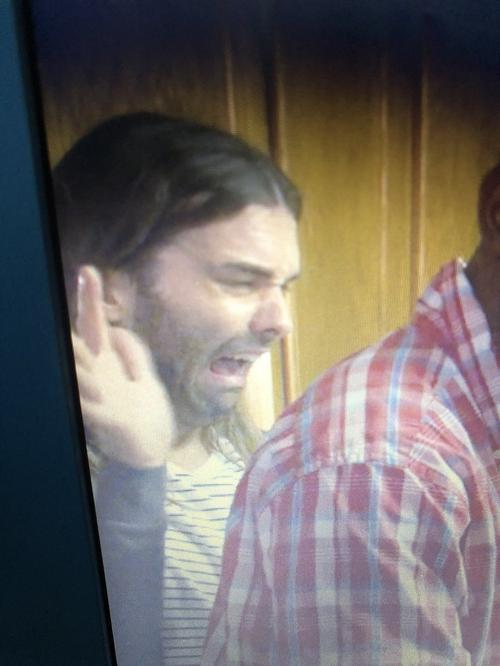

In [ ]:
from PIL import Image
from IPython.display import display
import os, random

img_dir = "/content/MMHS150K/img_resized"
img_file = random.choice(os.listdir(img_dir))
img = Image.open(os.path.join(img_dir, img_file))

display(img)


In [ ]:
import os
import json
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

In [ ]:
import torch
import torchvision

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

Torch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA: True


In [ ]:
import os
import json                                   # FIX M2 -- needed for JSON OCR loader
import re
from PIL import Image
from torch.utils.data import Dataset


def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9!?., ]", "", text)
    return text


class MMHS150KDataset(Dataset):
    def __init__(self, root_dir, id_list, transform=None, max_samples=None):
        self.root_dir = root_dir
        self.transform = transform
        self.ids = id_list

        if max_samples is not None:
            import random
            random.shuffle(self.ids)
            self.ids = self.ids[:max_samples]

        label_file = os.path.join(root_dir, "MMHS150K_GT.json")
        with open(label_file, "r") as f:
            self.labels = json.load(f)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        sample_id = self.ids[idx]

        # -------- IMAGE --------
        img_path = os.path.join(self.root_dir, "img_resized", f"{sample_id}.jpg")
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)


        txt_path = os.path.join(self.root_dir, "img_txt", f"{sample_id}.txt")
        if os.path.exists(txt_path):
            try:
                with open(txt_path, "r", encoding="utf-8") as f:
                    ocr_text = json.load(f).get("img_text", "").strip()
            except Exception:
                with open(txt_path, "r", encoding="utf-8") as f:
                    ocr_text = f.read().strip()
        else:
            ocr_text = ""

        # -------- TWEET TEXT --------
        tweet_text = self.labels[sample_id].get("tweet_text", "")

        combined = (ocr_text + " " + tweet_text).strip()
        text = clean_text(combined)              # for custom transformer
        raw_text = combined                       # for DistilBERT (no cleaning)

        # -------- LABEL --------
        label_list = self.labels[sample_id]["labels"]
        label = max(set(label_list), key=label_list.count)

        return {
            "image": image,
            "text": text,
            "raw_text": raw_text,
            "label": label,
        }

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
import os
import json
import math
import torch
import torch.nn as nn
import numpy as np

from collections import Counter
from torch.utils.data import DataLoader
from torchvision.models import vit_b_16, ViT_B_16_Weights

In [ ]:
def build_vocab_fast(root_dir, id_list, min_freq=1, log_every=20000):
    counter = Counter()
    ids = id_list   # ✅ use dynamic ids

    with open(os.path.join(root_dir, "MMHS150K_GT.json")) as f:
        gt = json.load(f)

    total = len(ids)

    for i, sid in enumerate(ids):

        # -------- OCR TEXT --------
        txt_path = os.path.join(root_dir, "img_txt", f"{sid}.txt")
        if os.path.exists(txt_path):
            try:
                with open(txt_path, "r", encoding="utf-8") as f:
                    ocr_text = json.load(f).get("img_text", "")
            except Exception:
                with open(txt_path, "r", encoding="utf-8") as f:
                    ocr_text = f.read()

            if ocr_text:
                cleaned_ocr = clean_text(ocr_text)
                counter.update(cleaned_ocr.split())

        # -------- TWEET TEXT --------
        tweet_text = gt[sid].get("tweet_text", "")
        if tweet_text:
            cleaned_tweet = clean_text(tweet_text)  # ✅ FIX
            counter.update(cleaned_tweet.split())

        if (i + 1) % log_every == 0:
            print(f"Processed {i+1}/{total}")

    vocab = {"<PAD>": 0, "<UNK>": 1}
    idx = 2
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1

    return vocab


In [ ]:
def encode_text(text, vocab, max_len=64):
    tokens = text.split()

    token_ids = []
    for tok in tokens[:max_len]:
        token_ids.append(vocab.get(tok, vocab["<UNK>"]))

    while len(token_ids) < max_len:
        token_ids.append(vocab["<PAD>"])

    return token_ids


In [ ]:
from transformers import AutoTokenizer

social_tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
def collate_fn(batch, vocab):

    images = torch.stack([
        item["image"] for item in batch
    ])

    labels = torch.tensor(
        [item["label"] for item in batch],
        dtype=torch.long
    )

    # =====================================================
    # CUSTOM TEXT TRANSFORMER INPUT
    # =====================================================

    text_ids = []

    for item in batch:

        token_ids = encode_text(
            item["text"],
            vocab,
            max_len=64
        )

        text_ids.append(token_ids)

    text_ids = torch.tensor(
        text_ids,
        dtype=torch.long
    )

    # =====================================================
    # SOCIAL ENCODER INPUT
    # =====================================================

    raw_texts = [
        item["raw_text"] for item in batch
    ]

    social_encoding = social_tokenizer(
        raw_texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    return {

        "images": images,

        "texts": text_ids,

        "social_input_ids":
            social_encoding["input_ids"],

        "social_attention_mask":
            social_encoding["attention_mask"],

        "labels": labels
    }

In [ ]:
vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
vit.heads = nn.Identity()

for param in vit.parameters():
    param.requires_grad = False

# 🔥 Unfreeze last 2 transformer blocks
for param in vit.encoder.layers[-2:].parameters():
    param.requires_grad = True


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:06<00:00, 54.9MB/s]


In [ ]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

#custom text transformer which we have
class TextTransformer(nn.Module):
    def __init__(
        self,
         vocab_size,
        embed_dim=256,
        num_heads=8,
        num_layers=6,
        max_len=64
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoder = PositionalEncoding(embed_dim, max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=512,
            dropout=0.2,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

    def forward(self, x):
        mask = (x == 0)  # PAD tokens

        x = self.embedding(x)
        x = self.pos_encoder(x)

        x = self.transformer(x, src_key_padding_mask=mask)

        #  masked mean pooling
        mask = (~mask).unsqueeze(-1)
        x = x * mask
        x = x.sum(dim=1) / mask.sum(dim=1).clamp(min=1)

        return x


In [ ]:
class CrossModalFusion(nn.Module):

    def __init__(
        self,
        img_dim=768,
        txt_dim=256,
        social_dim=768,
        fused_dim=256,
        num_layers=2,
        num_heads=4
    ):
        super().__init__()

        self.img_proj = nn.Linear(img_dim, fused_dim)
        self.txt_proj = nn.Linear(txt_dim, fused_dim)
        self.social_proj = nn.Linear(social_dim, fused_dim)


        self.cls_token = nn.Parameter(torch.randn(1, 1, fused_dim) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=fused_dim,
            nhead=num_heads,
            dim_feedforward=2048,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, img_feat, txt_feat, social_feat):
        img = self.img_proj(img_feat).unsqueeze(1)        # [B, 1, 256]
        txt = self.txt_proj(txt_feat).unsqueeze(1)        # [B, 1, 256]
        soc = self.social_proj(social_feat).unsqueeze(1)  # [B, 1, 256]

        B = img.size(0)
        cls = self.cls_token.expand(B, -1, -1)            # [B, 1, 256]


        seq = torch.cat([cls, img, txt, soc], dim=1)      # [B, 4, 256]
        seq = self.transformer(seq)


        return seq[:, 0]                                  # [B, 256]

In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



# 1. MLP (PRIMARY)
class MLPClassifier(nn.Module):
    def __init__(self, input_dim=256, num_classes=6):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.fc(x)


class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=256, num_classes=6):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_dim, nhead=4,
            dim_feedforward=512, dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        # x is already pooled [B, 256] -> treat as 1 token
        x = x.unsqueeze(1)
        x = self.transformer(x).squeeze(1)
        return self.fc(x)



class CNNClassifier(nn.Module):
    def __init__(self, input_dim=256, num_classes=6):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveMaxPool1d(64)
        self.fc = nn.Linear(64 * 64, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)              # [B, 1, 256]
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.flatten(1)
        return self.fc(x)



class BiLSTMClassifier(nn.Module):
    def __init__(self, input_dim=256, hidden=128, num_classes=6):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(2 * hidden, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        _, (h, _) = self.lstm(x)
        h = torch.cat((h[-2], h[-1]), dim=1)
        return self.fc(h)

In [ ]:
class MultimodalHateModel(nn.Module):

    def __init__(self, vit, text_model, social_encoder, fusion_model, classifier):
        super().__init__()
        self.vit = vit
        self.text_model = text_model
        self.social_encoder = social_encoder       # kept for compatibility; unused in ablation
        self.fusion_model = fusion_model
        self.classifier = classifier


    def train(self, mode=True):
        super().train(mode)
        self.social_encoder.eval()
        return self

    def forward(self, images, texts, social_input_ids, social_attention_mask):

        # ---------- IMAGE ----------
        img_feat = self.vit(images)                          # [B, 768]

        # ---------- TEXT ----------
        txt_feat = self.text_model(texts)                    # [B, 256]


        social_feat = torch.zeros(
            images.size(0), 768, device=images.device
        )


        fused_feat = self.fusion_model(img_feat, txt_feat, social_feat)


        logits = self.classifier(fused_feat)
        return logits

In [ ]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    total_loss = 0

    for batch in loader:

        # =====================================================
        # LOAD BATCH
        # =====================================================

        images = batch["images"].to(device)

        texts = batch["texts"].to(device)

        social_input_ids = batch[
            "social_input_ids"
        ].to(device)

        social_attention_mask = batch[
            "social_attention_mask"
        ].to(device)

        labels = batch["labels"].to(device)

        # =====================================================
        # ZERO GRADIENTS
        # =====================================================

        optimizer.zero_grad()

        # =====================================================
        # FORWARD PASS
        # =====================================================

        logits = model(
            images,
            texts,
            social_input_ids,
            social_attention_mask
        )

        # =====================================================
        # LOSS
        # =====================================================

        loss = criterion(
            logits,
            labels
        )

        # =====================================================
        # BACKPROP
        # =====================================================

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        # =====================================================
        # TRACK LOSS
        # =====================================================

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
from transformers import AutoModel

class SocialEntropyDistilBERT(nn.Module):

    def __init__(self):
        super().__init__()

        self.distilbert = AutoModel.from_pretrained(
            "distilbert-base-uncased"
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(768, 1)

    def forward(
        self,
        input_ids,
        attention_mask
    ):

        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # =====================================================
        # FIX M4 -- MASKED MEAN POOLING (must match Notebook 1)
        # =====================================================
        mask = attention_mask.unsqueeze(-1).float()
        social_embedding = (outputs.last_hidden_state * mask).sum(dim=1) \
                           / mask.sum(dim=1).clamp(min=1)

        dropped = self.dropout(
            social_embedding
        )

        entropy = self.fc(
            dropped
        ).squeeze()

        return entropy, social_embedding

In [ ]:
social_encoder = SocialEntropyDistilBERT()

checkpoint = torch.load(
    "/content/drive/MyDrive/social_encoder_distilbert_best.pt",
    map_location=device,
    weights_only=False
)

social_encoder.load_state_dict(
    checkpoint["model_state_dict"]
)

social_encoder = social_encoder.to(device)

for param in social_encoder.parameters():
    param.requires_grad = False

social_encoder.eval()

print("✅ Frozen Social Encoder Loaded!")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Frozen Social Encoder Loaded!


In [ ]:
import time
from sklearn.metrics import f1_score
from torch.amp import GradScaler, autocast

device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
scaler = GradScaler(device_type)

def train_and_validate(
    model, train_loader, val_loader, optimizer, criterion, device,
    epochs=5,                          # FIX M9 -- was 1
    start_epoch=0,
    early_stop_patience=2,             # FIX M9 -- new
    checkpoint_path="/content/drive/MyDrive/mmhs_checkpoint.pt"
):

    best_f1 = -1.0
    no_improve = 0

    for epoch in range(start_epoch, start_epoch + epochs):
        t0 = time.time()
        model.train()
        total_loss = 0.0

        for i, batch in enumerate(train_loader):
            images = batch["images"].to(device)
            texts = batch["texts"].to(device)
            sii = batch["social_input_ids"].to(device)
            sam = batch["social_attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type=device_type):
                logits = model(images, texts, sii, sam)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            if (i + 1) % 500 == 0:
                print(f"  Processed {i+1}/{len(train_loader)} batches")

        avg_train_loss = total_loss / len(train_loader)

        # ---------- VALIDATION ----------
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                images = batch["images"].to(device)
                texts = batch["texts"].to(device)
                sii = batch["social_input_ids"].to(device)
                sam = batch["social_attention_mask"].to(device)
                labels = batch["labels"].to(device)
                preds = model(images, texts, sii, sam).argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_acc = (np.array(all_preds) == np.array(all_labels)).mean()
        val_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        epoch_time = (time.time() - t0) / 60

        print(f"\nEpoch [{epoch+1}] | TrainLoss: {avg_train_loss:.4f} | "
              f"ValAcc: {val_acc:.4f} | ValMacroF1: {val_f1:.4f} | "
              f"Time: {epoch_time:.1f} min")

        # ---------- BEST CHECKPOINT + EARLY STOP ----------
        if val_f1 > best_f1:
            best_f1 = val_f1
            no_improve = 0
            torch.save({
                "epoch": epoch + 1,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_f1": float(val_f1),
                "val_acc": float(val_acc),
            }, checkpoint_path)
            print(f"  💾 New best F1={val_f1:.4f} saved")
        else:
            no_improve += 1
            print(f"  ⏳ No F1 improvement ({no_improve}/{early_stop_patience})")
            if no_improve >= early_stop_patience:
                print(f"  ⏹ Early stop. Best F1 = {best_f1:.4f}")
                break

    return best_f1

In [ ]:
import os

checkpoint_path = "/content/drive/MyDrive/mmhs_checkpoint.pt"

if os.path.exists(checkpoint_path):
    os.remove(checkpoint_path)
    print("✅ Old checkpoint deleted! Training will start fresh.")
else:
    print("No old checkpoint found.")

No old checkpoint found.


In [ ]:
class_names = [
    "Non-Hateful",
    "Racist",
    "Sexist",
    "Religion-based",
    "Homophobe",
    "Other"
]


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

split_configs = [
    # ("80/10/10", 0.80, 0.10, 0.10, 42),
    # ("70/20/10", 0.70, 0.20, 0.10, 999),
    ("75/15/10", 0.75, 0.15, 0.10, 123)

]

all_results = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class labels for confusion matrix display
CLASS_LABELS = ['NotHate', 'Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']



def cache_features(model, loader, device):
    model.eval()
    feats, labels_out = [], []
    with torch.no_grad():
        for batch in loader:
            images = batch["images"].to(device)
            texts = batch["texts"].to(device)
            labels = batch["labels"]

            img_feat = model.vit(images)
            txt_feat = model.text_model(texts)

            # ABLATION -- zeros instead of SE
            social_feat = torch.zeros(images.size(0), 768, device=device)
            # _, social_feat = model.social_encoder(sii, sam)

            fused = model.fusion_model(img_feat, txt_feat, social_feat)
            feats.append(fused.cpu())
            labels_out.append(labels)
    return torch.cat(feats), torch.cat(labels_out)

def train_classifier_head(clf, train_X, train_y, val_X, val_y,
                          criterion, device, epochs=20, lr=1e-3, batch=512):
    clf = clf.to(device)
    opt = torch.optim.AdamW(clf.parameters(), lr=lr)
    ds = TensorDataset(train_X, train_y)
    loader = DataLoader(ds, batch_size=batch, shuffle=True)

    best_f1, best_state = -1.0, None
    val_X_d, val_y_np = val_X.to(device), val_y.numpy()

    for ep in range(epochs):
        clf.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = criterion(clf(xb), yb)
            loss.backward()
            opt.step()

        clf.eval()
        with torch.no_grad():
            preds = clf(val_X_d).argmax(dim=1).cpu().numpy()
        f1 = f1_score(val_y_np, preds, average="macro", zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.cpu().clone() for k, v in clf.state_dict().items()}

    clf.load_state_dict(best_state)
    return clf



for split_name, tr, v, te, seed in split_configs:

    print("\n" + "=" * 70)
    print(f"🚀 PROCESSING SPLIT: {split_name}")
    print("=" * 70)

    train_ids, val_ids, test_ids, y_train, y_val, y_test = get_split_ids(tr, v, te, seed)

    # ----- vocab + datasets -----
    vocab = build_vocab_fast("/content/MMHS150K", train_ids, min_freq=5)

    train_dataset = MMHS150KDataset("/content/MMHS150K", train_ids, transform=train_transform)
    val_dataset   = MMHS150KDataset("/content/MMHS150K", val_ids,   transform=test_transform)
    test_dataset  = MMHS150KDataset("/content/MMHS150K", test_ids,  transform=test_transform)


    class_counts = np.bincount(y_train, minlength=6)
    class_counts_safe = np.where(class_counts == 0, 1, class_counts)

    train_loader = DataLoader(
        train_dataset, batch_size=96,
        shuffle=True,
        num_workers=2, pin_memory=True,
        collate_fn=lambda b: collate_fn(b, vocab)
    )
    val_loader = DataLoader(
        val_dataset, batch_size=96, shuffle=False,
        num_workers=2, pin_memory=True,
        collate_fn=lambda b: collate_fn(b, vocab)
    )
    test_loader = DataLoader(
        test_dataset, batch_size=96, shuffle=False,
        num_workers=2, pin_memory=True,
        collate_fn=lambda b: collate_fn(b, vocab)
    )

    cw = torch.tensor(1.0 / (class_counts_safe ** 0.3),
                      dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=cw)


    print("\n--- STAGE 1: train encoders + fusion + primary MLP head ---")

    vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
    vit.heads = nn.Identity()
    for p in vit.parameters():
        p.requires_grad = False
    for p in vit.encoder.layers[-2:].parameters():
        p.requires_grad = True
    vit = vit.to(device)

    text_model   = TextTransformer(len(vocab)).to(device)
    fusion_model = CrossModalFusion().to(device)
    primary_head = MLPClassifier().to(device)

    model = MultimodalHateModel(
        vit, text_model, social_encoder, fusion_model, primary_head
    ).to(device)

    optimizer = torch.optim.AdamW([
        {"params": text_model.parameters(),                "lr": 1e-4},
        {"params": fusion_model.parameters(),              "lr": 1e-4},
        {"params": primary_head.parameters(),              "lr": 1e-4},
        {"params": vit.encoder.layers[-2:].parameters(),   "lr": 1e-5},
    ])

    stage1_ckpt = f"/content/drive/MyDrive/mmhs_stage1_NoSE_{split_name.replace('/', '_')}.pt"
    train_and_validate(
        model, train_loader, val_loader, optimizer, criterion, device,
        epochs=5,
        early_stop_patience=2,
        checkpoint_path=stage1_ckpt
    )

    print("\n--- STAGE 2: caching fused features ---")
    train_X, train_y = cache_features(model, train_loader, device)
    val_X,   val_y   = cache_features(model, val_loader,   device)
    test_X,  test_y  = cache_features(model, test_loader,  device)

    cache_path = f"/content/drive/MyDrive/fused_cache_NoSE_{split_name.replace('/', '_')}.pt"
    torch.save({
        "train": (train_X, train_y),
        "val":   (val_X,   val_y),
        "test":  (test_X,  test_y),
    }, cache_path)
    print(f"  Cached: train {tuple(train_X.shape)} | val {tuple(val_X.shape)} | test {tuple(test_X.shape)}")


    print("\n--- STAGE 3: train 4 classifier heads on cached features ---")
    split_results = []
    best_f1, best_cm, best_model_name = -1.0, None, None

    head_factory = [
        ("MLP",         MLPClassifier),
        ("Transformer", TransformerClassifier),
        ("CNN",         CNNClassifier),
        ("BiLSTM",      BiLSTMClassifier),
    ]

    for head_name, head_cls in head_factory:
        head = head_cls()
        head = train_classifier_head(
            head, train_X, train_y, val_X, val_y,
            criterion=nn.CrossEntropyLoss(weight=cw),
            device=device, epochs=20
        )

        head.eval()
        with torch.no_grad():
            preds = head(test_X.to(device)).argmax(dim=1).cpu().numpy()
        true = test_y.numpy()

        cm   = confusion_matrix(true, preds)
        acc  = accuracy_score(true, preds)
        prec = precision_score(true, preds, average="macro", zero_division=0)
        rec  = recall_score(true, preds, average="macro", zero_division=0)
        f1   = f1_score(true, preds, average="macro", zero_division=0)

        print(f"  ✅ {head_name:12s} Acc={acc:.4f}  Prec={prec:.4f}  "
              f"Rec={rec:.4f}  F1={f1:.4f}")

        if f1 > best_f1:
            best_f1, best_cm, best_model_name = f1, cm, head_name

        result = {
            "Split Ratio":     split_name,
            "Classifier":      head_name,
            "Accuracy":        round(acc, 4),
            "Macro Precision": round(prec, 4),
            "Macro Recall":    round(rec, 4),
            "Macro F1-Score":  round(f1, 4),
        }
        split_results.append(result)
        all_results.append(result)


    print("\n" + "=" * 70)
    print(f"🏆 BEST MODEL for {split_name}: {best_model_name} "
          f"(Macro F1: {best_f1:.4f})")
    print("=" * 70)

    # ===== (a) Confusion matrix with row/column labels =====
    print(f"\n📊 Confusion Matrix ({split_name} Split - {best_model_name} Classifier)")
    print(f"   (Fig. X equivalent)")
    cm_df = pd.DataFrame(best_cm, index=CLASS_LABELS, columns=CLASS_LABELS)
    cm_df.index.name = "Actual \\ Pred"
    display(cm_df)

    # ===== (b) Best classifier as one-row table (Table V row) =====
    print(f"\n📋 PERFORMANCE COMPARISON ACROSS DATASET SPLITS")
    print(f"   (Table V row for {split_name})")
    best_row = [r for r in split_results if r["Classifier"] == best_model_name][0]
    best_row_df = pd.DataFrame([{
        "Data Split":      split_name,
        "Model":           best_row["Classifier"],
        "Accuracy":        best_row["Accuracy"],
        "Macro Precision": best_row["Macro Precision"],
        "Macro Recall":    best_row["Macro Recall"],
        "Macro F1-Score":  best_row["Macro F1-Score"],
    }])
    display(best_row_df)

    # ===== (c) Full table -- all 4 classifiers (Table VI) =====
    print(f"\n📊 CLASSIFIER PERFORMANCE ON FUSED FEATURES ({split_name} SPLIT)")
    print(f"   (Table VI equivalent)")
    split_df = pd.DataFrame(split_results)
    display(split_df[["Classifier", "Accuracy", "Macro Precision",
                      "Macro Recall", "Macro F1-Score"]])



df = pd.DataFrame(all_results)

print("\n" + "=" * 70)
print("🏁 FINAL SPLIT PERFORMANCE (BEST MODELS)")
print("=" * 70)

final_table = df.loc[
    df.groupby("Split Ratio")["Macro F1-Score"].idxmax()
].reset_index(drop=True)

display(final_table)


🚀 PROCESSING SPLIT: 75/15/10
Processed 20000/112367
Processed 40000/112367
Processed 60000/112367
Processed 80000/112367
Processed 100000/112367

--- STAGE 1: train encoders + fusion + primary MLP head ---
  Processed 500/1171 batches
  Processed 1000/1171 batches


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(



Epoch [1] | TrainLoss: 0.8537 | ValAcc: 0.7951 | ValMacroF1: 0.3573 | Time: 23.1 min
  💾 New best F1=0.3573 saved
  Processed 500/1171 batches
  Processed 1000/1171 batches

Epoch [2] | TrainLoss: 0.7413 | ValAcc: 0.7756 | ValMacroF1: 0.3991 | Time: 22.6 min
  💾 New best F1=0.3991 saved
  Processed 500/1171 batches
  Processed 1000/1171 batches

Epoch [3] | TrainLoss: 0.7167 | ValAcc: 0.7847 | ValMacroF1: 0.3641 | Time: 23.0 min
  ⏳ No F1 improvement (1/2)
  Processed 500/1171 batches
  Processed 1000/1171 batches

Epoch [4] | TrainLoss: 0.6926 | ValAcc: 0.8039 | ValMacroF1: 0.4237 | Time: 22.8 min
  💾 New best F1=0.4237 saved
  Processed 500/1171 batches
  Processed 1000/1171 batches

Epoch [5] | TrainLoss: 0.6680 | ValAcc: 0.7905 | ValMacroF1: 0.4159 | Time: 22.6 min
  ⏳ No F1 improvement (1/2)

--- STAGE 2: caching fused features ---
  Cached: train (112367, 256) | val (22473, 256) | test (14983, 256)

--- STAGE 3: train 4 classifier heads on cached features ---
  ✅ MLP          Ac

,NotHate,Racist,Sexist,Homophobe,Religion,OtherHate
Actual \ Pred,,,,,,
NotHate,10390,470,412,432,16,576
Racist,852,350,9,14,1,12
Sexist,275,4,121,16,0,3
Homophobe,106,2,19,280,1,1
Religion,11,1,0,0,4,6
OtherHate,194,24,4,3,3,371



📋 PERFORMANCE COMPARISON ACROSS DATASET SPLITS
   (Table V row for 75/15/10)


,Data Split,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
0,75/15/10,MLP,0.7686,0.4038,0.4837,0.4285



📊 CLASSIFIER PERFORMANCE ON FUSED FEATURES (75/15/10 SPLIT)
   (Table VI equivalent)


,Classifier,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
0,MLP,0.7686,0.4038,0.4837,0.4285
1,Transformer,0.7701,0.4084,0.4807,0.4238
2,CNN,0.7627,0.3941,0.4816,0.4156
3,BiLSTM,0.7714,0.4037,0.4636,0.4179



🏁 FINAL SPLIT PERFORMANCE (BEST MODELS)


,Split Ratio,Classifier,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
0,75/15/10,MLP,0.7686,0.4038,0.4837,0.4285
